# 1. Import Libraries

In this section, we import all required libraries for the project.


In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing libraries
import re
import string
import nltk
import spacy

# NLTK tools
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Machine learning libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# WordCloud
from wordcloud import WordCloud

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')

# Load spaCy English model
# Run this command first if model is missing:
# python -m spacy download en_core_web_sm

nlp = spacy.load("en_core_web_sm")

print("Libraries imported successfully")


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nsti-\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nsti-\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Libraries imported successfully


# 2. Load Dataset

The uploaded dataset is in `.bz2` compressed format.

We will read the dataset directly using pandas.


In [2]:
# Load Amazon review dataset

# Dataset file name
file_name = "train.ft.txt.bz2"

# Load only first 100000 rows
data = pd.read_csv(
    file_name,
    compression='bz2',
    sep='\t',
    header=None,
    names=['review'],
    nrows=100000
)

print("Dataset Loaded Successfully")

# Show first 5 rows
print(data.head())

# Show dataset shape
print("Dataset Shape:", data.shape)

Dataset Loaded Successfully
                                              review
0  __label__2 Stuning even for the non-gamer: Thi...
1  __label__2 The best soundtrack ever to anythin...
2  __label__2 Amazing!: This soundtrack is my fav...
3  __label__2 Excellent Soundtrack: I truly like ...
4  __label__2 Remember, Pull Your Jaw Off The Flo...
Dataset Shape: (100000, 1)


# 3. Create Review Text and Rating

The dataset contains labels and review text together.

We separate them into:
- sentiment label
- review text


In [3]:
# Extract labels
data['label'] = data['review'].apply(lambda x: x.split(' ')[0])

# Extract review text
data['text'] = data['review'].apply(lambda x: ' '.join(x.split(' ')[1:]))

# Show data
data[['label', 'text']].head()


,label,text
0,__label__2,Stuning even for the non-gamer: This sound tra...
1,__label__2,The best soundtrack ever to anything.: I'm rea...
2,__label__2,Amazing!: This soundtrack is my favorite music...
3,__label__2,Excellent Soundtrack: I truly like this soundt...
4,__label__2,"Remember, Pull Your Jaw Off The Floor After He..."


# 4. Create Sentiment Labels

We create:
- Positive
- Negative

Since this dataset already contains positive and negative labels,
we convert them into readable format.


In [4]:
# Convert labels

def sentiment_label(x):
    
    if x == '__label__2':
        return 'Positive'
    else:
        return 'Negative'

data['sentiment'] = data['label'].apply(sentiment_label)

# Check sentiment counts
data['sentiment'].value_counts()


sentiment
Positive    51267
Negative    48733
Name: count, dtype: int64

# 6. Data Cleaning and Text Preprocessing

We perform:

- Lowercase conversion
- Remove punctuation
- Remove numbers
- Remove stopwords
- Tokenization
- Lemmatization


In [5]:
# Stopwords
stop_words = set(stopwords.words('english'))

# Text cleaning function
def clean_text(text):
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r'\\d+', '', text)
    
    # Tokenization
    words = word_tokenize(text)
    
    # Remove stopwords
    words = [word for word in words if word not in stop_words]
    
    # Lemmatization using spaCy
    doc = nlp(" ".join(words))
    
    clean_words = []
    
    for token in doc:
        clean_words.append(token.lemma_)
    
    # Join words again
    final_text = " ".join(clean_words)
    
    return final_text


In [6]:
# Apply cleaning

data['clean_text'] = data['text'].apply(clean_text)

# Show cleaned text
data[['text', 'clean_text']].head()


,text,clean_text
0,Stuning even for the non-gamer: This sound tra...,stun even nongamer sound track beautiful paint...
1,The best soundtrack ever to anything.: I'm rea...,good soundtrack ever anything I m read lot rev...
2,Amazing!: This soundtrack is my favorite music...,amazing soundtrack favorite music time hand in...
3,Excellent Soundtrack: I truly like this soundt...,excellent soundtrack truly like soundtrack enj...
4,"Remember, Pull Your Jaw Off The Floor After He...",remember pull jaw floor hear you ve play game ...


# 7. Exploratory Data Analysis (EDA)

Now we explore the dataset visually.


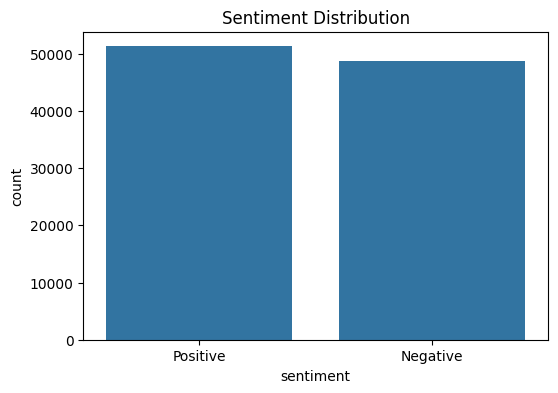

In [7]:
# Sentiment count plot

plt.figure(figsize=(6,4))

sns.countplot(x=data['sentiment'])

plt.title("Sentiment Distribution")

plt.show()


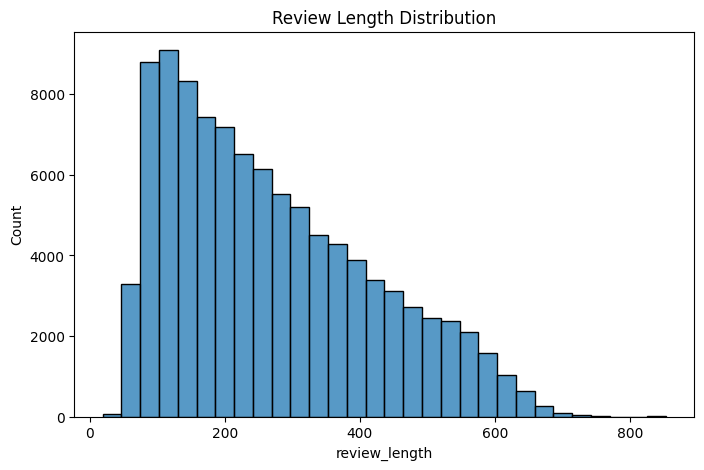

In [8]:
# Review length

data['review_length'] = data['clean_text'].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(data['review_length'], bins=30)

plt.title("Review Length Distribution")

plt.show()


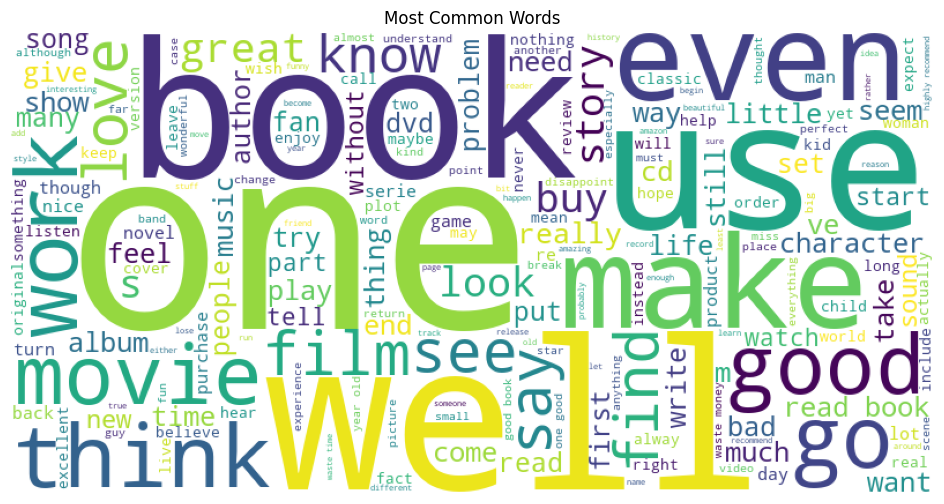

In [9]:
# WordCloud

all_words = " ".join(data['clean_text'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Most Common Words")

plt.show()


# 8. TF-IDF Vectorization

Machine learning models cannot understand text directly.

TF-IDF converts text into numerical form.


In [10]:
# TF-IDF vectorizer

tfidf = TfidfVectorizer(max_features=10000)

# Features
X = tfidf.fit_transform(data['clean_text'])

# Target
y = data['sentiment']

print("TF-IDF Shape:", X.shape)


TF-IDF Shape: (100000, 10000)


# 9. Train-Test Split

We divide data into:
- Training data
- Testing data


In [11]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)


Training Data: (80000, 10000)
Testing Data: (20000, 10000)


# 10. Logistic Regression Sentiment Model

We train a Logistic Regression model.


In [12]:
# Create model

model = LogisticRegression()

# Train model
model.fit(X_train, y_train)

print("Model training completed")


Model training completed


# 11. Model Evaluation

We check:
- Accuracy
- Classification Report
- Confusion Matrix


In [13]:
# Predictions

y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.8766


In [14]:
# Classification report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

    Negative       0.88      0.87      0.87      9602
    Positive       0.88      0.89      0.88     10398

    accuracy                           0.88     20000
   macro avg       0.88      0.88      0.88     20000
weighted avg       0.88      0.88      0.88     20000



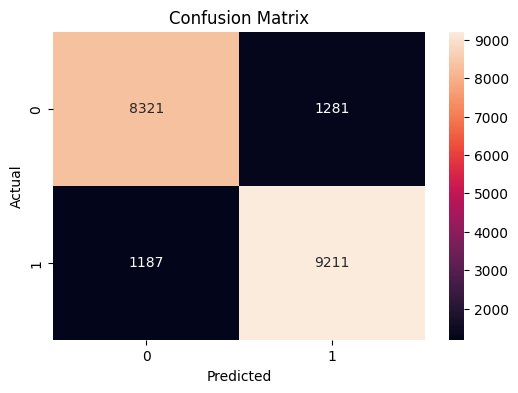

In [15]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


# 12. Fake Review Detection

We use simple rule-based logic.

Rules:
- Too short reviews
- Repeated words
- Too many positive words


In [16]:
# Positive words list

positive_words = [

    'amazing',
    'excellent',
    'perfect',
    'awesome',
    'great',
    'best',
    'fantastic',
    'super',
    'wonderful',
    'brilliant',
    'outstanding',
    'incredible',
    'nice',
    'beautiful',
    'love',
    'liked',
    'good',
    'happy',
    'satisfied',
    'impressive',
    'valuable',
    'premium',
    'fabulous',
    'terrific',
    'excellent',
    'recommend',
    'favorite',
    'perfectly',
    'fast',
    'smooth'
]

# Fake review detection function

def detect_fake_review(text):
    
    words = text.split()
    
    # Rule 1: Very short review
    if len(words) < 3:
        return "Fake Review"
    
    # Rule 2: Repeated words
    if len(set(words)) < len(words) / 2:
        return "Fake Review"
    
    # Rule 3: Too many positive words
    count = 0
    
    for word in words:
        if word in positive_words:
            count += 1
    
    if count >= 3:
        return "Fake Review"
    
    return "Real Review"


In [17]:
# Apply fake review detection

data['fake_review'] = data['clean_text'].apply(detect_fake_review)

# Show results
data[['clean_text', 'fake_review']].head()


,clean_text,fake_review
0,stun even nongamer sound track beautiful paint...,Real Review
1,good soundtrack ever anything I m read lot rev...,Real Review
2,amazing soundtrack favorite music time hand in...,Fake Review
3,excellent soundtrack truly like soundtrack enj...,Fake Review
4,remember pull jaw floor hear you ve play game ...,Fake Review


# 13. Issue Category Classification

Categories:
- Delivery
- Product Quality
- Packaging
- Customer Service


In [ ]:

# Issue classification function

def classify_issue(text, sentiment):

    text = text.lower()

    # Positive review
    if sentiment == 'Positive':
        return 'No Issue'

    # Empty list to store issues
    issues = []

    # Delivery issues
    if 'delivery' in text or 'late' in text or 'shipping' in text:
        issues.append('Delivery')

    # Product quality issues
    if 'broken' in text or 'quality' in text or 'bad' in text:
        issues.append('Product Quality')

    # Packaging issues
    if 'package' in text or 'packaging' in text or 'box' in text:
        issues.append('Packaging')

    # Customer service issues
    if 'support' in text or 'service' in text or 'customer' in text:
        issues.append('Customer Service')

    # If no issues found
    if len(issues) == 0:
        return 'No Issue'

    # Return all issues
    return ", ".join(issues)

In [19]:
# Apply issue classification

data['issue_category'] = data.apply(
    
    lambda row: classify_issue(
        row['clean_text'],
        row['sentiment']
    ),
    
    axis=1
)

# Display results in table format

data[
    ['clean_text', 'sentiment', 'issue_category']
].head(10)

,clean_text,sentiment,issue_category
0,stun even nongamer sound track beautiful paint...,Positive,No Issue
1,good soundtrack ever anything I m read lot rev...,Positive,No Issue
2,amazing soundtrack favorite music time hand in...,Positive,No Issue
3,excellent soundtrack truly like soundtrack enj...,Positive,No Issue
4,remember pull jaw floor hear you ve play game ...,Positive,No Issue
5,absolute masterpiece quite sure actually take ...,Positive,No Issue
6,buyer beware selfpublishe book want know whyre...,Negative,Product Quality
7,glorious story love whisper wicked saint story...,Positive,No Issue
8,five star book finish read whisper wicked sain...,Positive,No Issue
9,whisper wicked saint easy read book make want ...,Positive,No Issue


# 14. Final Prediction Function

This function predicts:
- Sentiment
- Fake Review Status
- Issue Category


In [20]:
# Final prediction function

def predict_review(review):
    
    # Clean text
    cleaned = clean_text(review)
    
    # Convert to TF-IDF
    vector = tfidf.transform([cleaned])
    
    # Predict sentiment
    sentiment = model.predict(vector)[0]
    
    # Fake review detection
    fake_status = detect_fake_review(cleaned)
    
    # Issue classification
    issue = classify_issue(cleaned, sentiment)
    
    # Print results
    print("Review:", review)
    print("")
    print("Predicted Sentiment:", sentiment)
    print("Fake Review Status:", fake_status)
    print("Issue Category:", issue)


In [21]:
# Test prediction

sample_review = "The product quality is bad and delivery was late"

predict_review(sample_review)


Review: The product quality is bad and delivery was late

Predicted Sentiment: Negative
Fake Review Status: Real Review
Issue Category: Delivery, Product Quality


# 15. Save Model and Vectorizer

We save the trained model for Streamlit app.


In [22]:
# Save model and vectorizer

import pickle

# Save model
pickle.dump(model, open('sentiment_model.pkl', 'wb'))

# Save TF-IDF vectorizer
pickle.dump(tfidf, open('tfidf_vectorizer.pkl', 'wb'))

print("Model files saved")


Model files saved
